In [1]:
import os
import sys
import pandas as pd

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from src.inference import CLIPInference
from src.aggregation import aggregate_video_scores
from src.metrics import evaluate
from src.config import AGGREGATION_METHOD, FINAL_THRESHOLD

In [2]:
model = CLIPInference()

TEXTS = [
    "a person fighting",
    "a robbery happening",
    "a violent action",
    "people walking normally",
    "a peaceful street scene"
]

model.set_text_prompts(TEXTS)

print("Model ready.")

Model ready.


In [3]:
manifest = pd.read_csv("../data/segments_manifest_16.csv")

test_df = manifest[manifest["split"] == "test"].copy()

print("Test segments:", len(test_df))
test_df.head()

Test segments: 307


,segment_uid,split,class,video_id,segment_id,num_frames,segment_path
519,test_Abuse_Abuse028_x264_seg_0000,test,Abuse,Abuse028_x264,seg_0000,16,test/Abuse/Abuse028_x264/seg_0000
520,test_Abuse_Abuse028_x264_seg_0001,test,Abuse,Abuse028_x264,seg_0001,16,test/Abuse/Abuse028_x264/seg_0001
521,test_Abuse_Abuse028_x264_seg_0002,test,Abuse,Abuse028_x264,seg_0002,16,test/Abuse/Abuse028_x264/seg_0002
522,test_Abuse_Abuse028_x264_seg_0003,test,Abuse,Abuse028_x264,seg_0003,16,test/Abuse/Abuse028_x264/seg_0003
523,test_Abuse_Abuse028_x264_seg_0004,test,Abuse,Abuse028_x264,seg_0004,16,test/Abuse/Abuse028_x264/seg_0004


In [5]:
results_test = []

for idx, row in test_df.iterrows():
    segment_path = row["segment_path"]
    full_path = os.path.join("..", "data", "segments_16", segment_path)

    prediction = model.predict_segment(full_path)

    results_test.append({
        "video_id": row["video_id"],
        "segment_uid": row["segment_uid"],
        "true_class": row["class"],
        "predicted_label": prediction["predicted_label"],
        "score": prediction["score"]
    })

results_test_df = pd.DataFrame(results_test)

print("Processed test segments:", len(results_test_df))

Processed test segments: 307


In [6]:
video_test_df = aggregate_video_scores(
    results_test_df,
    method=AGGREGATION_METHOD
)

video_test_df.head()

,video_id,score,true_class,is_anomaly
0,Abuse028_x264,0.256348,Abuse,True
1,Arrest001_x264,0.236572,Arrest,True
2,Arson007_x264,0.270264,Arson,True
3,Assault006_x264,0.252686,Assault,True
4,Burglary005_x264,0.255371,Burglary,True


In [7]:
test_metrics = evaluate(video_test_df, threshold=FINAL_THRESHOLD)

print("---- Test Metrics ----")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1: {test_metrics['f1']:.4f}")
print(f"AUC: {test_metrics['auc']:.4f}")
print(f"Used Threshold: {test_metrics['used_threshold']:.4f}")

---- Test Metrics ----
Accuracy: 0.9286
Precision: 0.9286
Recall: 1.0000
F1: 0.9630
AUC: 0.7692
Used Threshold: 0.2286


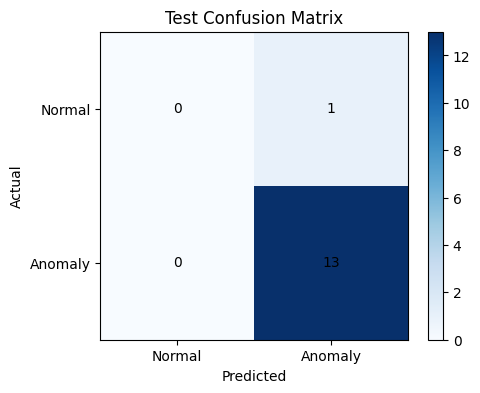

In [8]:
import numpy as np
import matplotlib.pyplot as plt

cm = test_metrics["confusion_matrix"]

conf_matrix = np.array([
    [cm["tn"], cm["fp"]],
    [cm["fn"], cm["tp"]]
])

plt.figure(figsize=(5,4))
plt.imshow(conf_matrix, cmap="Blues")

plt.xticks([0,1], ["Normal", "Anomaly"])
plt.yticks([0,1], ["Normal", "Anomaly"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix")
plt.colorbar()
plt.show()

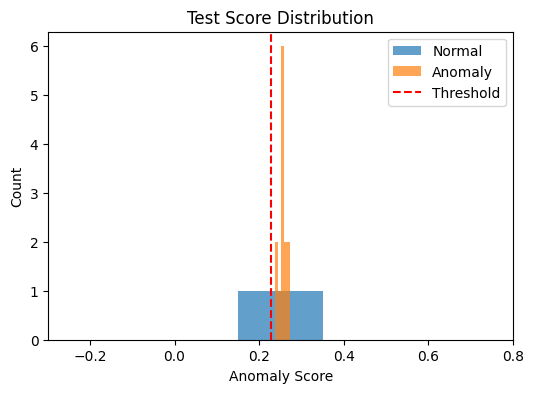

In [9]:
import matplotlib.pyplot as plt

normal_scores = video_test_df[video_test_df["is_anomaly"] == False]["score"]
anomaly_scores = video_test_df[video_test_df["is_anomaly"] == True]["score"]

plt.figure(figsize=(6,4))

plt.hist(normal_scores, bins=5, alpha=0.7, label="Normal")
plt.hist(anomaly_scores, bins=5, alpha=0.7, label="Anomaly")

plt.axvline(FINAL_THRESHOLD, color="red", linestyle="--", label="Threshold")

plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.title("Test Score Distribution")
plt.legend()
plt.show()

In [10]:
print("Normal video score:")
print(normal_scores.values)

print("\nAnomaly scores:")
print(anomaly_scores.values)

Normal video score:
[0.25097656]

Anomaly scores:
[0.25634766 0.23657227 0.27026367 0.25268555 0.25537109 0.27392578
 0.25610352 0.26293945 0.26147461 0.25170898 0.23828125 0.24475098
 0.25708008]


In [11]:
test_df["class"].value_counts()

class
Assault          50
Burglary         48
Arson            39
Stealing         30
Shoplifting      27
Explosion        25
Fighting         19
NormalVideos     17
Arrest           14
Abuse             8
Robbery           8
RoadAccidents     8
Shooting          7
Vandalism         7
Name: count, dtype: int64

In [12]:
video_test_df["true_class"].value_counts()

true_class
Abuse            1
Arrest           1
Arson            1
Assault          1
Burglary         1
Explosion        1
Fighting         1
NormalVideos     1
RoadAccidents    1
Robbery          1
Shooting         1
Shoplifting      1
Stealing         1
Vandalism        1
Name: count, dtype: int64

In [13]:
video_test_df.groupby("true_class")["score"].mean().sort_values(ascending=False)

true_class
Explosion        0.273926
Arson            0.270264
RoadAccidents    0.262939
Robbery          0.261475
Vandalism        0.257080
Abuse            0.256348
Fighting         0.256104
Burglary         0.255371
Assault          0.252686
Shooting         0.251709
NormalVideos     0.250977
Stealing         0.244751
Shoplifting      0.238281
Arrest           0.236572
Name: score, dtype: float64